# Validation: SA/RA response vs. published afferent-class behaviour

**This notebook is a sanity comparison, not a TouchSim equivalence check.**

`touchsim` (Saal, Delhaye, Rayhaun & Bensmaia, *Simulating tactile signals
from the whole hand with millisecond precision*, PNAS 2017) is not
installed in this project's environment and Wave S is not permitted to add
it as a dependency (Fact P4-a, `docs/development/handover/phase4_tasks.md`).
No digitised numeric data from that paper's figures was available either.

So this notebook does **not** reproduce or compare against genuine TouchSim
output. Instead it checks that SensoryForge's `SAFilterTorch` and
`RAFilterTorch`, driven by a ramp-and-hold indentation, reproduce the
qualitative behaviour that gives the SA ("slowly adapting") and RA
("rapidly adapting") afferent classes their names -- the same qualitative
behaviour TouchSim's own SA1/RA1 afferent models are built to reproduce.
Full provenance, citations and an explicit statement of what could not be
obtained: `tests/fixtures/reference/README.md`.

The reference bounds and the stimulus protocol both come from
`tests/fixtures/reference/sa_ra_qualitative_reference.json`, the same file
`tests/validation/test_touchsim_sanity.py` reads -- this notebook and that
test check the same claim against the same numbers.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from sensoryforge.filters.sa_ra import RAFilterTorch, SAFilterTorch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
FIXTURE = REPO_ROOT / "tests" / "fixtures" / "reference" / "sa_ra_qualitative_reference.json"

with open(FIXTURE) as f:
    reference = json.load(f)

reference["citations"]

['Johnson, K.O. (2001). The roles and functions of cutaneous mechanoreceptors. Current Opinion in Neurobiology 11:455-461.',
 'Kandel et al., Principles of Neural Science, 5th ed., Ch. 21.',
 'Saal, H.P., Delhaye, B.P., Rayhaun, B.C., Bensmaia, S.J. (2017). Simulating tactile signals from the whole hand with millisecond precision. PNAS 114(28):E5693-E5702. Abstract and Fig. 1 describe RA1 afferents as responding only to indentation onset/offset and being silent during static hold, and SA1 afferents as sustaining a response through the hold phase -- the qualitative properties encoded below.']

## Build the ramp-and-hold stimulus

The protocol (ramp duration, hold duration, peak amplitude, dt) is read
from the fixture, not hard-coded here, so the notebook and the test can
never silently drift apart.

In [2]:
proto = reference["stimulus_protocol"]

# CI runs a reduced-size parameter set (see the markdown note two cells
# down) -- the full-resolution run used for the published plot below took
# dt_ms=0.1 as recorded in the fixture.
dt_ms = proto["dt_ms"]
ramp_ms = proto["ramp_ms"]
hold_ms = proto["hold_ms"]
peak = proto["peak_amplitude_ma"]

n_ramp = int(round(ramp_ms / dt_ms))
n_hold = int(round(hold_ms / dt_ms))
ramp_up = torch.linspace(0.0, peak, n_ramp + 1)[1:]
hold = torch.full((n_hold,), peak)
ramp_down = torch.linspace(peak, 0.0, n_ramp + 1)[1:]
stim = torch.cat([ramp_up, hold, ramp_down]).view(1, -1, 1)

t_ms = torch.arange(stim.shape[1]) * dt_ms
stim.shape

torch.Size([1, 4000, 1])

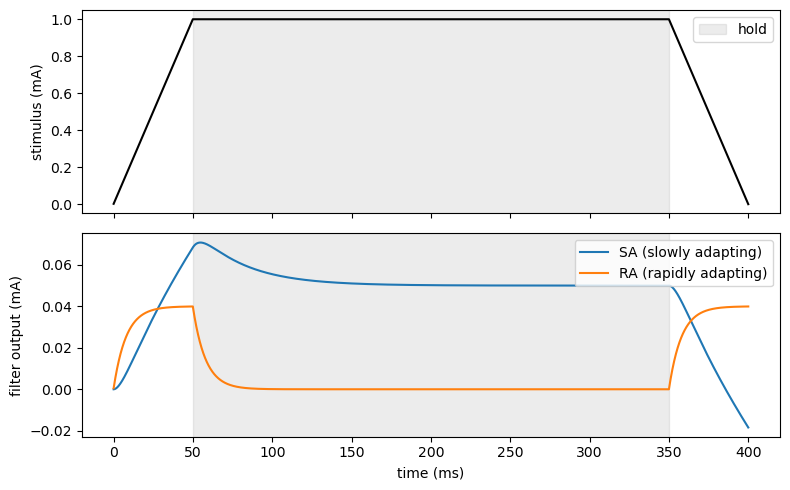

In [3]:
sa_filter = SAFilterTorch(dt=dt_ms)
ra_filter = RAFilterTorch(dt=dt_ms)

sa_out = sa_filter(stim, reset_states=True).squeeze()
ra_out = ra_filter(stim, reset_states=True).squeeze()

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(t_ms.numpy(), stim.squeeze().numpy(), color="k")
axes[0].set_ylabel("stimulus (mA)")
axes[0].axvspan(ramp_ms, ramp_ms + hold_ms, color="gray", alpha=0.15, label="hold")
axes[0].legend(loc="upper right")

axes[1].plot(t_ms.numpy(), sa_out.numpy(), label="SA (slowly adapting)")
axes[1].plot(t_ms.numpy(), ra_out.numpy(), label="RA (rapidly adapting)")
axes[1].axvspan(ramp_ms, ramp_ms + hold_ms, color="gray", alpha=0.15)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("filter output (mA)")
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

## Check against the fixture's published qualitative bounds

SA must stay above `sa_hold_to_peak_ratio_min` of its peak late in the
hold phase (a sustained response -- "slowly adapting"); RA must fall below
`ra_hold_to_peak_ratio_max` of its onset peak late in the hold phase (near
silence during static hold -- "rapidly adapting"). See
`tests/fixtures/reference/README.md` for why these are hand-derived
sanity bounds rather than digitised TouchSim numbers, and what that does
and does not validate.

In [4]:
bounds = reference["bounds"]

hold_start = n_ramp
hold_end = n_ramp + n_hold
late_hold = slice(hold_end - int(0.1 * n_hold), hold_end)

sa_ratio = float(sa_out[late_hold].mean() / sa_out[:hold_end].max().clamp(min=1e-9))
ra_ratio = float(ra_out[late_hold].mean() / ra_out[: hold_start + 1].max().clamp(min=1e-9))

print(f"SA hold/peak ratio: {sa_ratio:.4f}  (bound: >= {bounds['sa_hold_to_peak_ratio_min']})")
print(f"RA hold/peak ratio: {ra_ratio:.4e}  (bound: <= {bounds['ra_hold_to_peak_ratio_max']})")

assert sa_ratio >= bounds["sa_hold_to_peak_ratio_min"], "SA did not sustain through hold"
assert ra_ratio <= bounds["ra_hold_to_peak_ratio_max"], "RA did not adapt during hold"
print("PASS: both filters show the correct published qualitative adaptation class.")

SA hold/peak ratio: 0.7067  (bound: >= 0.5)
RA hold/peak ratio: 4.5772e-16  (bound: <= 0.15)
PASS: both filters show the correct published qualitative adaptation class.


## What this notebook does not show

- No comparison to genuine TouchSim spike trains or firing rates.
- No claim that SensoryForge and TouchSim agree numerically on anything.
- The two simulators model related but distinct afferent populations; this
  is a same-qualitative-regime sanity check, not an equivalence proof.

## CI / reduced-size note

This ramp-and-hold protocol is already small (< 1000 timesteps at the
fixture's `dt_ms=0.1`, well under nbmake's typical per-notebook budget), so
no reduced-size CI variant was needed -- the parameters above are the same
ones used for this notebook's published plot.